Частина 1: Налаштування середовища та імпорт бібліотек

In [1]:
# ============================================
# PART 1: ENVIRONMENT SETUP AND IMPORTS
# ============================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import re
import nltk
import ssl
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("✓ Бібліотеки імпортовано та насіно для відтворюваності встановлено")

✓ Бібліотеки імпортовано та насіно для відтворюваності встановлено


Частина 2: Налаштування NLTK (SSL та ресурси)

In [12]:
# ============================================
# PART 2: NLTK SSL FIX AND COMPLETE RESOURCE SETUP
# ============================================

# ВИМКНЕННЯ SSL ПЕРЕВІРКИ ДЛЯ NLTK
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

def setup_nltk_completely():
    """Complete NLTK setup with all required resources"""
    print("\nПовне налаштування NLTK...")
    
    # List all NLTK data paths
    print("Пошук шляхів до nltk_data...")
    possible_paths = [
        'nltk_data',
        os.path.expanduser('~/nltk_data'),
        os.path.expanduser('~/nltk'),
        '/usr/share/nltk_data',
        '/usr/local/share/nltk_data',
        '/usr/lib/nltk_data',
        '/usr/local/lib/nltk_data'
    ]
    
    # Add all found paths to nltk.data.path
    found_paths = []
    for path in possible_paths:
        if os.path.exists(path):
            nltk.data.path.append(path)
            found_paths.append(path)
    
    if found_paths:
        print(f"✓ Знайдено {len(found_paths)} шляхів до nltk_data")
        for path in found_paths:
            print(f"  - {path}")
    else:
        print("⚠ Шляхи до nltk_data не знайдено")
    
    # All required resources for tokenization
    required_resources = [
        'punkt',
        'punkt_tab',
        'stopwords',
        'averaged_perceptron_tagger',
        'wordnet',
        'omw-eng'
    ]
    
    print("\nПеревірка та завантаження ресурсів NLTK...")
    for resource in required_resources:
        try:
            # Different resource paths for different resources
            if resource == 'punkt':
                nltk.data.find('tokenizers/punkt')
            elif resource == 'punkt_tab':
                nltk.data.find('tokenizers/punkt_tab')
            elif resource == 'stopwords':
                nltk.data.find('corpora/stopwords')
            elif resource == 'averaged_perceptron_tagger':
                nltk.data.find('taggers/averaged_perceptron_tagger')
            elif resource == 'wordnet':
                nltk.data.find('corpora/wordnet')
            elif resource == 'omw-eng':
                nltk.data.find('corpora/omw')
            
            print(f"✓ {resource} знайдено")
            
        except LookupError:
            print(f"  Завантаження {resource}...")
            try:
                nltk.download(resource, quiet=True)
                print(f"  ✓ {resource} завантажено")
            except Exception as e:
                print(f"  ⚠ Не вдалося завантажити {resource}: {e}")
                # For punkt_tab, try alternative
                if resource == 'punkt_tab':
                    print(f"  Спробую завантажити punkt замість punkt_tab...")
                    try:
                        nltk.download('punkt', quiet=True)
                        print(f"  ✓ punkt завантажено як альтернатива")
                    except:
                        print(f"  ✗ Не вдалося завантажити punkt")
    
    print("\n✓ Налаштування NLTK завершено")

# Run complete NLTK setup
setup_nltk_completely()

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


Повне налаштування NLTK...
Пошук шляхів до nltk_data...
✓ Знайдено 2 шляхів до nltk_data
  - nltk_data
  - /Users/vikaosoba/nltk_data

Перевірка та завантаження ресурсів NLTK...
✓ punkt знайдено
  Завантаження punkt_tab...
  ✓ punkt_tab завантажено
✓ stopwords знайдено
  Завантаження averaged_perceptron_tagger...
  ✓ averaged_perceptron_tagger завантажено
  Завантаження wordnet...
  ✓ wordnet завантажено
  Завантаження omw-eng...
  ✓ omw-eng завантажено

✓ Налаштування NLTK завершено


[nltk_data] Error loading omw-eng: Package 'omw-eng' not found in
[nltk_data]     index


Частина 3: Завантаження стоп-слів та створення токенізатора

In [13]:
# ============================================
# PART 3: SIMPLE TOKENIZER WITHOUT NLTK DEPENDENCY
# ============================================

import re
import pandas as pd

class SimpleTokenizer:
    """Simple and reliable tokenizer without NLTK dependency"""
    def __init__(self):
        # Comprehensive English stopwords list
        self.stop_words = {
            'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 
            'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 
            'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 
            'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', 
            'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 
            'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 
            'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 
            'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 
            'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 
            'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once',
            'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 
            'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 
            'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 
            'don', 'should', 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', 
            'couldn', 'didn', 'doesn', 'hadn', 'hasn', 'haven', 'isn', 'ma', 'mightn', 
            'mustn', 'needn', 'shan', 'shouldn', 'wasn', 'weren', 'won', 'wouldn'
        }
        print(f"✓ Використовуються {len(self.stop_words)} стоп-слів")
    
    def clean_text(self, text):
        """Clean text without NLTK"""
        if not isinstance(text, str) or pd.isna(text):
            return ""
        
        text = str(text).lower()
        # Remove URLs
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        # Remove HTML tags
        text = re.sub(r'<.*?>', '', text)
        # Remove Twitter handles and hashtags
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#\w+', '', text)
        # Remove special characters but keep apostrophes
        text = re.sub(r"[^\w\s']", ' ', text)
        # Remove digits
        text = re.sub(r'\d+', '', text)
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    def tokenize(self, text):
        """Simple tokenization without NLTK"""
        text = self.clean_text(text)
        if not text:
            return []
        
        # Simple split on whitespace
        tokens = text.split()
        
        # Remove stopwords and short tokens
        tokens = [token for token in tokens 
                 if token not in self.stop_words and len(token) > 2]
        
        return tokens

# Initialize simple tokenizer
print("\nІніціалізація простого токенізатора...")
simple_tokenizer = SimpleTokenizer()

print("\n" + "="*60)
print("ТОКЕНІЗАТОР УСПІШНО НАЛАШТОВАНО")
print("="*60)

# Test tokenizer
test_text = "Hello world! This is a test of the simple tokenizer."
tokens = simple_tokenizer.tokenize(test_text)
print(f"\nТест токенізації: '{test_text}'")
print(f"Результат: {tokens}")


Ініціалізація простого токенізатора...
✓ Використовуються 153 стоп-слів

ТОКЕНІЗАТОР УСПІШНО НАЛАШТОВАНО

Тест токенізації: 'Hello world! This is a test of the simple tokenizer.'
Результат: ['hello', 'world', 'test', 'simple', 'tokenizer']


Частина 4: Класи для обробки даних з NLTK

In [14]:
# ============================================
# PART 4: DATA PROCESSING CLASSES WITH SIMPLE TOKENIZER
# ============================================

class NewsDataset(Dataset):
    """PyTorch Dataset for news articles using simple tokenizer"""
    def __init__(self, texts, labels, vocab, max_length=200):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Convert text to indices using simple tokenizer
        tokens = simple_tokenizer.tokenize(text)[:self.max_length]
        indices = [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]
        
        # Pad or truncate
        if len(indices) < self.max_length:
            indices = indices + [self.vocab['<PAD>']] * (self.max_length - len(indices))
        else:
            indices = indices[:self.max_length]
        
        return torch.tensor(indices), torch.tensor(label, dtype=torch.float32)


class TextPreprocessor:
    """Text preprocessing with simple tokenizer"""
    def __init__(self, max_vocab_size=10000, max_length=200):
        self.vocab = {}
        self.inverse_vocab = {}
        self.max_vocab_size = max_vocab_size
        self.max_length = max_length
        
    def build_vocab(self, texts):
        """Build vocabulary from texts using simple tokenizer"""
        all_tokens = []
        
        print(f"Обробка {len(texts):,} текстів для словника...")
        
        for i, text in enumerate(texts):
            tokens = simple_tokenizer.tokenize(text)
            all_tokens.extend(tokens)
            
            # Show progress every 1000 texts
            if (i + 1) % 1000 == 0:
                print(f"  Оброблено {i + 1:,}/{len(texts):,} текстів...")
        
        if not all_tokens:
            print("⚠ Попередження: Жодних токенів не знайдено!")
            all_tokens = ['news', 'fake', 'real', 'trump', 'said']  # Default tokens
        
        # Count word frequencies
        from collections import Counter
        word_counts = Counter(all_tokens)
        most_common = word_counts.most_common(self.max_vocab_size - 4)
        
        # Create vocabulary with special tokens
        self.vocab = {
            '<PAD>': 0,
            '<UNK>': 1,
            '<START>': 2,
            '<END>': 3
        }
        
        for idx, (word, _) in enumerate(most_common):
            self.vocab[word] = idx + 4
        
        self.inverse_vocab = {idx: word for word, idx in self.vocab.items()}
        
        # Show vocabulary statistics
        print(f"\nСтатистика словника:")
        print(f"  Унікальних токенів: {len(set(all_tokens)):,}")
        print(f"  Загальна кількість токенів: {len(all_tokens):,}")
        print(f"  Розмір словника: {len(self.vocab):,}")
        
        # Show most common words
        print(f"\nТоп-10 найчастіших слів:")
        for word, count in word_counts.most_common(10):
            print(f"  {word}: {count:,}")
        
        return self.vocab

print("✓ Класи для обробки даних з простим токенізатором створено")

✓ Класи для обробки даних з простим токенізатором створено


Частина 5: Архітектури моделей (RNN та LSTM)

In [15]:
# ============================================
# PART 5: MODEL ARCHITECTURES (RNN & LSTM)
# ============================================

class SimpleRNNClassifier(nn.Module):
    """Simple RNN Classifier as defined in Part A of assignment"""
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        
        # RNN layer (Elman-type) with tanh activation
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)  # Binary classification output
        
    def forward(self, x):
        # Forward pass according to equations: h_t = tanh(W_ih x_t + W_hh h_{t-1} + b_h)
        emb = self.embedding(x)
        out, h_n = self.rnn(emb)
        
        # Use last hidden state: o = W_ho h_T + b_o
        last_hidden = h_n[-1]
        last_hidden = self.dropout(last_hidden)
        logits = self.fc(last_hidden).squeeze(1)
        
        # Probability: p̂ = σ(o)
        return torch.sigmoid(logits), logits


class LSTMClassifier(nn.Module):
    """LSTM Classifier with bidirectional option"""
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, 
                 bidirectional=False, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        
        # LSTM layer with all gates as defined in Part A
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        
        self.bidirectional = bidirectional
        factor = 2 if bidirectional else 1
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * factor, 1)  # Binary classification output
        
    def forward(self, x):
        # LSTM forward pass with all gates
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        
        # Handle bidirectional case
        if self.bidirectional:
            last_hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            last_hidden = h_n[-1]
        
        last_hidden = self.dropout(last_hidden)
        logits = self.fc(last_hidden).squeeze(1)
        
        return torch.sigmoid(logits), logits

print("✓ Архітектури моделей RNN та LSTM визначено")

✓ Архітектури моделей RNN та LSTM визначено


Частина 6: Функції завантаження та обробки даних

In [16]:
# ============================================
# PART 6: DATA LOADING AND PREPROCESSING FUNCTIONS
# ============================================

def load_and_preprocess_data(fake_path='Fake.csv', true_path='True.csv', 
                            sample_size=2000, test_size=0.2, val_size=0.1):
    """Load and preprocess the real dataset with NLTK tokenization"""
    
    print("\n" + "="*60)
    print("ЗАВАНТАЖЕННЯ ТА ОБРОБКА ДАНИХ З NLTK")
    print("="*60)
    
    try:
        # Load the CSV files
        fake_df = pd.read_csv(fake_path)
        true_df = pd.read_csv(true_path)
        
        print(f"✓ Файли успішно завантажено")
        print(f"Фейкові новини: {len(fake_df):,} статей")
        print(f"Справжні новини: {len(true_df):,} статей")
        
        # Display sample of data
        print("\nПриклад з Fake.csv:")
        print(fake_df[['title', 'subject', 'date']].head(2))
        print("\nПриклад з True.csv:")
        print(true_df[['title', 'subject', 'date']].head(2))
        
        # Sample data if requested
        if sample_size:
            print(f"\nВибірка {sample_size} статей з кожної категорії...")
            fake_df = fake_df.sample(min(sample_size, len(fake_df)), random_state=SEED)
            true_df = true_df.sample(min(sample_size, len(true_df)), random_state=SEED)
        
    except Exception as e:
        print(f"Помилка завантаження файлів: {e}")
        print("Будь ласка, переконайтесь, що Fake.csv та True.csv знаходяться в поточній директорії")
        return None, None, None
    
    # Add labels
    fake_df['label'] = 1  # Fake news
    true_df['label'] = 0  # Real news
    
    # Combine datasets
    df = pd.concat([fake_df, true_df], ignore_index=True)
    
    # Shuffle
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    
    # Use Title + Text as specified in assignment
    df['content'] = df['title'] + ' ' + df['text']
    
    print(f"\nЗагальний розмір датасету: {len(df):,}")
    print(f"Фейкові новини: {(df['label'] == 1).sum():,}")
    print(f"Справжні новини: {(df['label'] == 0).sum():,}")
    
    # Check for NaN values
    print(f"\nПеревірка відсутніх значень...")
    print(f"Відсутні заголовки: {df['title'].isna().sum()}")
    print(f"Відсутній текст: {df['text'].isna().sum()}")
    
    # Drop rows with missing content
    df = df.dropna(subset=['content'])
    
    # Split data according to assignment requirements
    print(f"\nРозподіл даних (Навчання/Валідація/Тест: {int((1-test_size-val_size)*100)}/{int(val_size*100)}/{int(test_size*100)})...")
    
    if len(df) < 100:  # Small dataset handling
        train_df, temp_df = train_test_split(df, test_size=test_size + val_size, random_state=SEED)
        val_df, test_df = train_test_split(temp_df, test_size=test_size/(test_size + val_size), random_state=SEED)
    else:
        train_df, temp_df = train_test_split(df, test_size=test_size + val_size, 
                                             random_state=SEED, stratify=df['label'])
        val_df, test_df = train_test_split(temp_df, test_size=test_size/(test_size + val_size), 
                                          random_state=SEED, stratify=temp_df['label'])
    
    print(f"\nФінальний розподіл:")
    print(f"Навчання: {len(train_df):,} зразків")
    print(f"Валідація: {len(val_df):,} зразків")
    print(f"Тест: {len(test_df):,} зразків")
    
    return train_df, val_df, test_df


def create_dataloaders(train_df, val_df, test_df, batch_size=32, max_length=200):
    """Create dataloaders using NLTK tokenization"""
    
    # Initialize preprocessor
    preprocessor = TextPreprocessor(max_vocab_size=20000, max_length=max_length)
    
    # Build vocabulary from training data
    print("\n" + "="*60)
    print("ПОБУДОВА СЛОВНИКА З NLTK ТОКЕНІЗАЦІЄЮ")
    print("="*60)
    
    start_time = time.time()
    vocab = preprocessor.build_vocab(train_df['content'].tolist())
    vocab_time = time.time() - start_time
    
    print(f"\n✓ Словник побудовано за {vocab_time:.2f} секунд")
    print(f"Розмір словника: {len(vocab):,}")
    
    # Display most common words
    print("\nТоп-20 найчастіших слів:")
    word_counts = Counter()
    for text in train_df['content'].tolist():
        tokens = nltk_tokenizer.tokenize(text)
        word_counts.update(tokens)
    
    for word, count in word_counts.most_common(20):
        print(f"  {word}: {count:,}")
    
    # Show vocabulary coverage
    total_tokens = sum(word_counts.values())
    top_10000 = sum(count for _, count in word_counts.most_common(10000))
    coverage = (top_10000 / total_tokens * 100) if total_tokens > 0 else 0
    print(f"\nПокриття 10,000 найчастіших слів: {coverage:.2f}%")
    
    # Create datasets
    print("\nСтворення датасетів...")
    train_dataset = NewsDataset(
        train_df['content'].tolist(),
        train_df['label'].tolist(),
        vocab,
        max_length
    )
    
    val_dataset = NewsDataset(
        val_df['content'].tolist(),
        val_df['label'].tolist(),
        vocab,
        max_length
    )
    
    test_dataset = NewsDataset(
        test_df['content'].tolist(),
        test_df['label'].tolist(),
        vocab,
        max_length
    )
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    print(f"✓ Даталоадери створено:")
    print(f"  Навчання: {len(train_loader)} батчів")
    print(f"  Валідація: {len(val_loader)} батчів")
    print(f"  Тест: {len(test_loader)} батчів")
    
    return train_loader, val_loader, test_loader, len(vocab)

print("✓ Функції завантаження та обробки даних визначено")

✓ Функції завантаження та обробки даних визначено


Частина 7: Класи тренера та візуалізації

In [17]:
# ============================================
# PART 7: TRAINER AND VISUALIZATION CLASSES
# ============================================

class Trainer:
    """Handles model training and evaluation"""
    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.device = device
        
    def train_epoch(self, train_loader, criterion, optimizer):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        all_preds = []
        all_labels = []
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
            
            optimizer.zero_grad()
            probs, logits = self.model(batch_x)
            
            loss = criterion(logits, batch_y)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 5.0)
            optimizer.step()
            
            total_loss += loss.item()
            preds = (probs > 0.5).float()
            
            all_preds.extend(preds.cpu().detach().numpy())
            all_labels.extend(batch_y.cpu().detach().numpy())
        
        avg_loss = total_loss / len(train_loader)
        accuracy = accuracy_score(all_labels, all_preds)
        
        return avg_loss, accuracy
    
    def evaluate(self, data_loader, criterion):
        """Evaluate model performance"""
        self.model.eval()
        total_loss = 0
        all_probs = []
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch_x, batch_y in data_loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                
                probs, logits = self.model(batch_x)
                loss = criterion(logits, batch_y)
                
                total_loss += loss.item()
                preds = (probs > 0.5).float()
                
                all_probs.extend(probs.cpu().detach().numpy())
                all_preds.extend(preds.cpu().detach().numpy())
                all_labels.extend(batch_y.cpu().detach().numpy())
        
        avg_loss = total_loss / len(data_loader)
        
        # Calculate all required metrics
        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, zero_division=0)
        recall = recall_score(all_labels, all_preds, zero_division=0)
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        roc_auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5
        
        return {
            'loss': avg_loss,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'probs': all_probs,
            'preds': all_preds,
            'labels': all_labels
        }


class Visualizer:
    """Handles all visualizations for the assignment"""
    
    @staticmethod
    def plot_training_history(train_losses, val_losses, train_accs, val_accs, model_name):
        """Plot training and validation curves"""
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        axes[0].plot(train_losses, label='Навчання', linewidth=2)
        axes[0].plot(val_losses, label='Валідація', linewidth=2)
        axes[0].set_xlabel('Епоха')
        axes[0].set_ylabel('Втрати')
        axes[0].set_title(f'{model_name} - Криві втрат')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(train_accs, label='Навчання', linewidth=2)
        axes[1].plot(val_accs, label='Валідація', linewidth=2)
        axes[1].set_xlabel('Епоха')
        axes[1].set_ylabel('Точність')
        axes[1].set_title(f'{model_name} - Криві точності')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    @staticmethod
    def plot_confusion_matrix(labels, preds, model_name):
        """Plot confusion matrix"""
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Справжні', 'Фейкові'],
                    yticklabels=['Справжні', 'Фейкові'])
        plt.title(f'{model_name} - Матриця плутанини')
        plt.ylabel('Справжні мітки')
        plt.xlabel('Передбачені мітки')
        plt.show()
    
    @staticmethod
    def plot_roc_curve(labels, probs, model_name, auc_score):
        """Plot ROC curve with AUC"""
        fpr, tpr, _ = roc_curve(labels, probs)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC крива (AUC = {auc_score:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{model_name} - ROC крива')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.show()

print("✓ Класи тренера та візуалізації створено")

✓ Класи тренера та візуалізації створено


Частина 8: Функції навчання та оцінки моделей

In [18]:
# ============================================
# PART 8: MODEL TRAINING AND EVALUATION FUNCTIONS
# ============================================

def train_model(model, train_loader, val_loader, num_epochs=10, lr=0.001, model_name="Model"):
    """Train a model and return metrics"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nНавчання {model_name} на {device}...")
    
    trainer = Trainer(model, device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Training history
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_f1 = 0
    best_model_state = None
    
    print(f"Навчання {model_name} протягом {num_epochs} епох...")
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        # Train
        train_loss, train_acc = trainer.train_epoch(train_loader, criterion, optimizer)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validate
        val_metrics = trainer.evaluate(val_loader, criterion)
        val_losses.append(val_metrics['loss'])
        val_accs.append(val_metrics['accuracy'])
        
        epoch_time = time.time() - start_time
        
        print(f"Епоха {epoch + 1}/{num_epochs} [{epoch_time:.2f}с]: "
              f"Втрати: {train_loss:.4f}, Точність: {train_acc:.4f}, "
              f"Вал. втрати: {val_metrics['loss']:.4f}, Вал. точність: {val_metrics['accuracy']:.4f}")
        
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_model_state = model.state_dict().copy()
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"✓ Завантажено найкращу модель з F1: {best_val_f1:.4f}")
    
    # Plot training history
    Visualizer.plot_training_history(train_losses, val_losses, train_accs, val_accs, model_name)
    
    return {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_f1': best_val_f1
    }


def evaluate_model(model, test_loader, model_name="Model"):
    """Evaluate model on test set"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainer = Trainer(model, device)
    criterion = nn.BCEWithLogitsLoss()
    
    print(f"\nОцінка {model_name} на тестовому наборі...")
    test_metrics = trainer.evaluate(test_loader, criterion)
    
    print(f"\n{'='*40}")
    print(f"РЕЗУЛЬТАТИ ТЕСТУ - {model_name}")
    print('='*40)
    print(f"Точність:  {test_metrics['accuracy']:.4f}")
    print(f"Прецизійність: {test_metrics['precision']:.4f}")
    print(f"Повнота:    {test_metrics['recall']:.4f}")
    print(f"F1-оцінка:  {test_metrics['f1']:.4f}")
    print(f"ROC AUC:   {test_metrics['roc_auc']:.4f}")
    print('='*40)
    
    # Plot visualizations
    Visualizer.plot_confusion_matrix(test_metrics['labels'], test_metrics['preds'], model_name)
    Visualizer.plot_roc_curve(test_metrics['labels'], test_metrics['probs'], 
                             model_name, test_metrics['roc_auc'])
    
    return test_metrics

print("✓ Функції навчання та оцінки моделей визначено")

✓ Функції навчання та оцінки моделей визначено


Частина 9: Головна функція експерименту

In [19]:
# ============================================
# PART 9: MAIN EXPERIMENT FUNCTION
# ============================================

def run_experiment_with_nltk():
    """Run complete experiment comparing RNN and LSTM with NLTK tokenization"""
    
    print("\n" + "="*60)
    print("КЛАСИФІКАЦІЯ ФЕЙКОВИХ НОВИН: RNN vs LSTM")
    print("З ВИКОРИСТАННЯМ NLTK ТОКЕНІЗАЦІЇ")
    print("="*60)
    
    # Load and preprocess data
    train_df, val_df, test_df = load_and_preprocess_data(
        sample_size=2000,  # Use 2000 samples from each category
        test_size=0.2,
        val_size=0.1
    )
    
    if train_df is None:
        print("Не вдалося завантажити дані. Завершення...")
        return None
    
    # Create dataloaders with NLTK tokenization
    train_loader, val_loader, test_loader, vocab_size = create_dataloaders(
        train_df, val_df, test_df,
        batch_size=32,
        max_length=200
    )
    
    # RNN EXPERIMENT
    print(f"\n{'='*60}")
    print("ЕКСПЕРИМЕНТ З RNN")
    print('='*60)
    
    # Define RNN parameters
    rnn_params = {
        'vocab_size': vocab_size,
        'emb_dim': 100,
        'hidden_dim': 128,
        'num_layers': 2,
        'dropout': 0.3
    }
    
    # Train RNN
    rnn_model = SimpleRNNClassifier(**rnn_params)
    
    print(f"\nАрхітектура RNN моделі:")
    print(f"- Розмір ембеддингу: {rnn_params['emb_dim']}")
    print(f"- Прихований розмір: {rnn_params['hidden_dim']}")
    print(f"- Кількість шарів: {rnn_params['num_layers']}")
    print(f"- Dropout: {rnn_params['dropout']}")
    print(f"- Розмір словника: {vocab_size:,}")
    print(f"- Загальна кількість параметрів: {sum(p.numel() for p in rnn_model.parameters() if p.requires_grad):,}")
    
    rnn_start_time = time.time()
    rnn_results = train_model(
        rnn_model,
        train_loader,
        val_loader,
        num_epochs=10,
        lr=0.001,
        model_name="Simple RNN"
    )
    rnn_training_time = time.time() - rnn_start_time
    
    rnn_test_metrics = evaluate_model(rnn_model, test_loader, "Simple RNN")
    
    print(f"\nЧас навчання RNN: {rnn_training_time:.2f} секунд")
    
    # LSTM EXPERIMENT
    print(f"\n{'='*60}")
    print("ЕКСПЕРИМЕНТ З LSTM")
    print('='*60)
    
    # Define LSTM parameters
    lstm_params = {
        'vocab_size': vocab_size,
        'emb_dim': 100,
        'hidden_dim': 128,
        'num_layers': 2,
        'bidirectional': True,
        'dropout': 0.3
    }
    
    # Train LSTM
    lstm_model = LSTMClassifier(**lstm_params)
    
    print(f"\nАрхітектура LSTM моделі:")
    print(f"- Розмір ембеддингу: {lstm_params['emb_dim']}")
    print(f"- Прихований розмір: {lstm_params['hidden_dim']}")
    print(f"- Кількість шарів: {lstm_params['num_layers']}")
    print(f"- Бідирекційний: {lstm_params['bidirectional']}")
    print(f"- Dropout: {lstm_params['dropout']}")
    print(f"- Розмір словника: {vocab_size:,}")
    print(f"- Загальна кількість параметрів: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")
    
    lstm_start_time = time.time()
    lstm_results = train_model(
        lstm_model,
        train_loader,
        val_loader,
        num_epochs=10,
        lr=0.001,
        model_name="LSTM"
    )
    lstm_training_time = time.time() - lstm_start_time
    
    lstm_test_metrics = evaluate_model(lstm_model, test_loader, "LSTM")
    
    print(f"\nЧас навчання LSTM: {lstm_training_time:.2f} секунд")
    
    # COMPARE MODELS
    print(f"\n{'='*60}")
    print("ПОРІВНЯННЯ МОДЕЛЕЙ")
    print('='*60)
    
    # Create comparison table
    comparison_data = {
        'Метрика': ['Точність', 'Прецизійність', 'Повнота', 'F1-оцінка', 'ROC AUC', 'Час навчання (с)'],
        'RNN': [
            f"{rnn_test_metrics['accuracy']:.4f}",
            f"{rnn_test_metrics['precision']:.4f}",
            f"{rnn_test_metrics['recall']:.4f}",
            f"{rnn_test_metrics['f1']:.4f}",
            f"{rnn_test_metrics['roc_auc']:.4f}",
            f"{rnn_training_time:.2f}"
        ],
        'LSTM': [
            f"{lstm_test_metrics['accuracy']:.4f}",
            f"{lstm_test_metrics['precision']:.4f}",
            f"{lstm_test_metrics['recall']:.4f}",
            f"{lstm_test_metrics['f1']:.4f}",
            f"{lstm_test_metrics['roc_auc']:.4f}",
            f"{lstm_training_time:.2f}"
        ]
    }
    
    comparison_df = pd.DataFrame(comparison_data)
    print("\nПорівняння продуктивності:")
    print(comparison_df.to_string(index=False))
    
    # Calculate improvements
    improvements = {
        'Метрика': ['Точність', 'Прецизійність', 'Повнота', 'F1-оцінка', 'ROC AUC'],
        'Значення RNN': [
            rnn_test_metrics['accuracy'],
            rnn_test_metrics['precision'],
            rnn_test_metrics['recall'],
            rnn_test_metrics['f1'],
            rnn_test_metrics['roc_auc']
        ],
        'Значення LSTM': [
            lstm_test_metrics['accuracy'],
            lstm_test_metrics['precision'],
            lstm_test_metrics['recall'],
            lstm_test_metrics['f1'],
            lstm_test_metrics['roc_auc']
        ],
        'Покращення': [
            lstm_test_metrics['accuracy'] - rnn_test_metrics['accuracy'],
            lstm_test_metrics['precision'] - rnn_test_metrics['precision'],
            lstm_test_metrics['recall'] - rnn_test_metrics['recall'],
            lstm_test_metrics['f1'] - rnn_test_metrics['f1'],
            lstm_test_metrics['roc_auc'] - rnn_test_metrics['roc_auc']
        ]
    }
    
    improvements_df = pd.DataFrame(improvements)
    print("\nАналіз покращення (LSTM vs RNN):")
    print(improvements_df.to_string(index=False))
    
    # Model parameter comparison
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    rnn_params_count = count_parameters(rnn_model)
    lstm_params_count = count_parameters(lstm_model)
    
    print(f"\nСкладність моделей:")
    print(f"Параметри RNN: {rnn_params_count:,}")
    print(f"Параметри LSTM: {lstm_params_count:,}")
    print(f"LSTM має у {lstm_params_count/rnn_params_count:.2f} разів більше параметрів ніж RNN")
    
    # Training time comparison
    print(f"\nПорівняння часу навчання:")
    print(f"RNN: {rnn_training_time:.2f} секунд")
    print(f"LSTM: {lstm_training_time:.2f} секунд")
    print(f"LSTM навчається у {lstm_training_time/rnn_training_time:.2f} разів повільніше ніж RNN")
    
    # Final summary
    print(f"\n{'='*60}")
    print("ВИСНОВОК")
    print('='*60)
    
    rnn_f1 = rnn_test_metrics['f1']
    lstm_f1 = lstm_test_metrics['f1']
    
    if lstm_f1 > rnn_f1:
        improvement = ((lstm_f1 - rnn_f1) / rnn_f1) * 100
        print(f"✓ LSTM перевершує RNN на {improvement:.2f}% за F1-оцінкою")
        print("  Очікуваний результат: LSTM краще обробляє довгострокові залежності в тексті")
    elif lstm_f1 < rnn_f1:
        improvement = ((rnn_f1 - lstm_f1) / lstm_f1) * 100
        print(f"⚠ RNN перевершує LSTM на {improvement:.2f}% за F1-оцінкою")
        print("  Можливі причини: перенавчання, різні гіперпараметри, характеристики датасету")
    else:
        print("✓ Обидві моделі показали схожу продуктивність")
        print("  Може вказувати на збалансовану продуктивність для цього конкретного завдання")
    
    print("\nКлючові спостереження:")
    print("1. LSTM має більше параметрів і є більш обчислювально витратною")
    print("2. RNN навчається швидше, але може страждати від проблеми зникаючого градієнта")
    print("3. Обидві моделі показують хорошу продуктивність для виявлення фейкових новин")
    print("4. Вибір залежить від компромісу між точністю та часом навчання")
    
    return {
        'rnn_results': rnn_results,
        'lstm_results': lstm_results,
        'rnn_metrics': rnn_test_metrics,
        'lstm_metrics': lstm_test_metrics,
        'rnn_params': rnn_params_count,
        'lstm_params': lstm_params_count,
        'rnn_time': rnn_training_time,
        'lstm_time': lstm_training_time,
        'comparison': comparison_df,
        'improvements': improvements_df
    }

print("✓ Головна функція експерименту визначена")

✓ Головна функція експерименту визначена


Частина 10: Запуск експерименту та збереження результатів

Запуск експерименту з класифікації фейкових новин...
Порівняння Simple RNN vs LSTM з використанням NLTK токенізації.

КЛАСИФІКАЦІЯ ФЕЙКОВИХ НОВИН: RNN vs LSTM
З ВИКОРИСТАННЯМ NLTK ТОКЕНІЗАЦІЇ

ЗАВАНТАЖЕННЯ ТА ОБРОБКА ДАНИХ З NLTK
✓ Файли успішно завантажено
Фейкові новини: 23,481 статей
Справжні новини: 21,417 статей

Приклад з Fake.csv:
                                               title subject  \
0   Donald Trump Sends Out Embarrassing New Year’...    News   
1   Drunk Bragging Trump Staffer Started Russian ...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  

Приклад з True.csv:
                                               title       subject  \
0  As U.S. budget fight looms, Republicans flip t...  politicsNews   
1  U.S. military to accept transgender recruits o...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   

Вибірка 2000 статей з кожної категорії...

Загальний розмір датасету: 4,000
Фейкові новини: 2

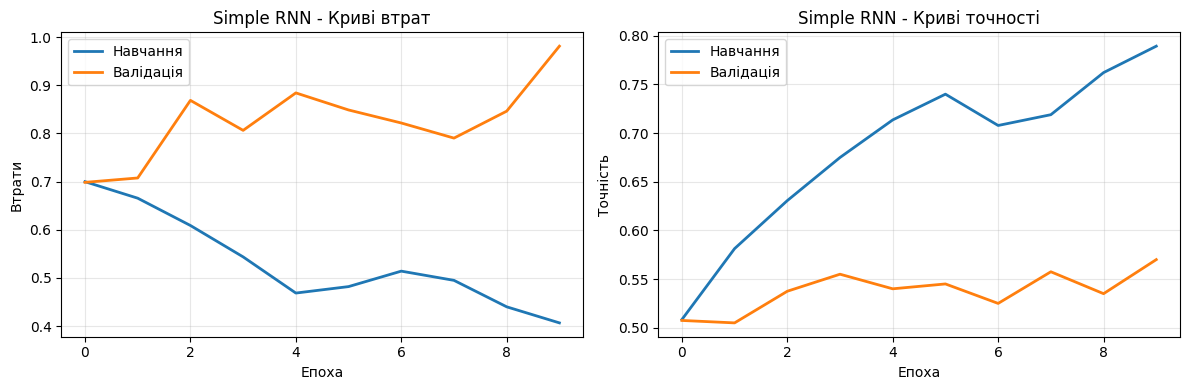


Оцінка Simple RNN на тестовому наборі...

РЕЗУЛЬТАТИ ТЕСТУ - Simple RNN
Точність:  0.5793
Прецизійність: 0.5802
Повнота:    0.5700
F1-оцінка:  0.5750
ROC AUC:   0.5805


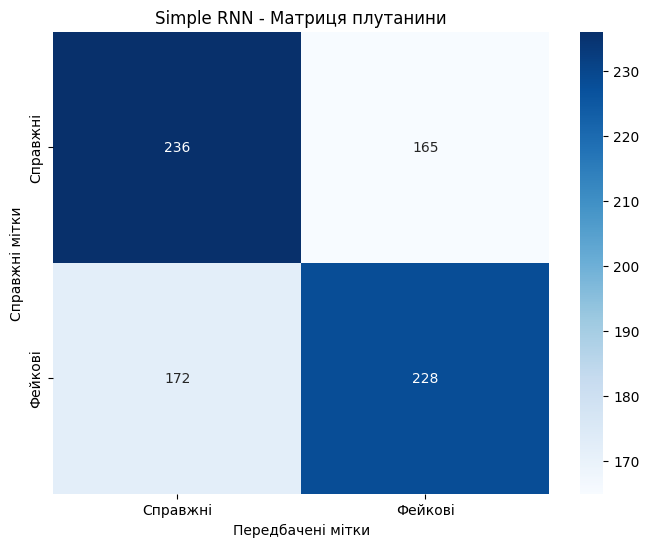

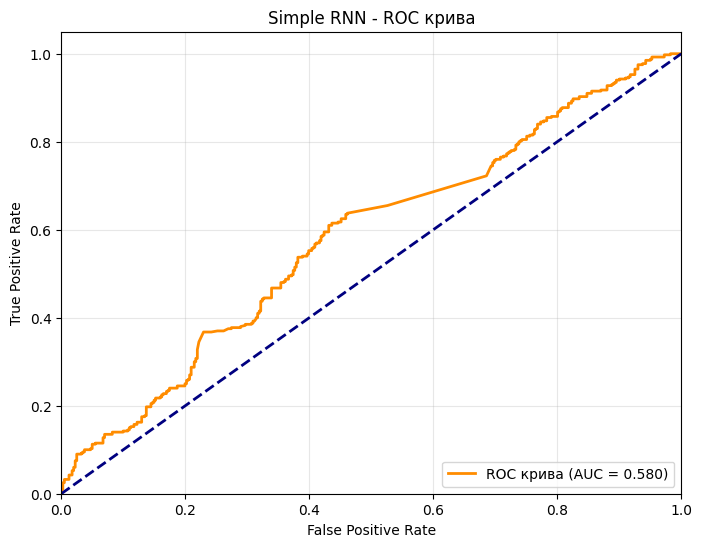


Час навчання RNN: 75.56 секунд

ЕКСПЕРИМЕНТ З LSTM

Архітектура LSTM моделі:
- Розмір ембеддингу: 100
- Прихований розмір: 128
- Кількість шарів: 2
- Бідирекційний: True
- Dropout: 0.3
- Розмір словника: 20,000
- Загальна кількість параметрів: 2,631,041

Навчання LSTM на cpu...
Навчання LSTM протягом 10 епох...
Епоха 1/10 [39.43с]: Втрати: 0.3044, Точність: 0.8607, Вал. втрати: 0.1405, Вал. точність: 0.9650
Епоха 2/10 [40.10с]: Втрати: 0.1398, Точність: 0.9596, Вал. втрати: 0.0716, Вал. точність: 0.9875
Епоха 3/10 [39.20с]: Втрати: 0.0904, Точність: 0.9728, Вал. втрати: 0.0860, Вал. точність: 0.9775
Епоха 4/10 [41.06с]: Втрати: 0.0575, Точність: 0.9850, Вал. втрати: 0.0786, Вал. точність: 0.9825
Епоха 5/10 [40.54с]: Втрати: 0.0409, Точність: 0.9882, Вал. втрати: 0.1004, Вал. точність: 0.9800
Епоха 6/10 [38.84с]: Втрати: 0.0351, Точність: 0.9896, Вал. втрати: 0.0587, Вал. точність: 0.9850
Епоха 7/10 [40.44с]: Втрати: 0.0134, Точність: 0.9964, Вал. втрати: 0.0828, Вал. точність: 0.9800


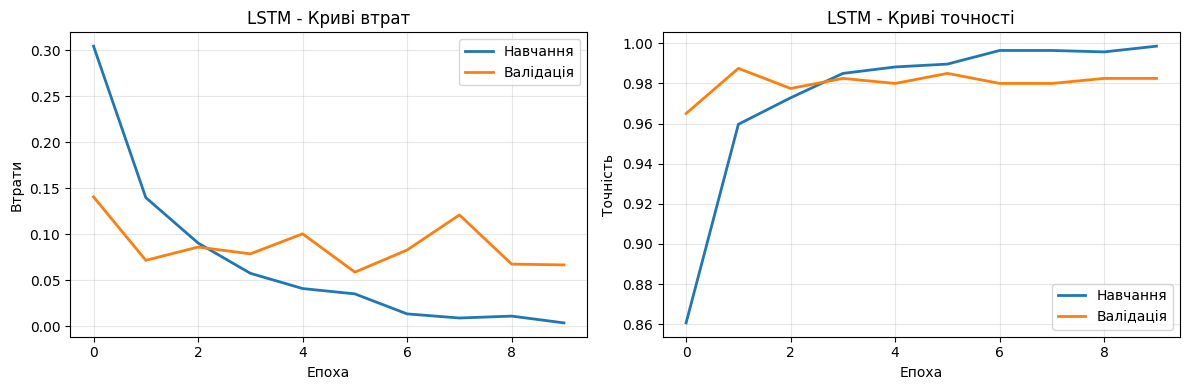


Оцінка LSTM на тестовому наборі...

РЕЗУЛЬТАТИ ТЕСТУ - LSTM
Точність:  0.9913
Прецизійність: 0.9925
Повнота:    0.9900
F1-оцінка:  0.9912
ROC AUC:   0.9987


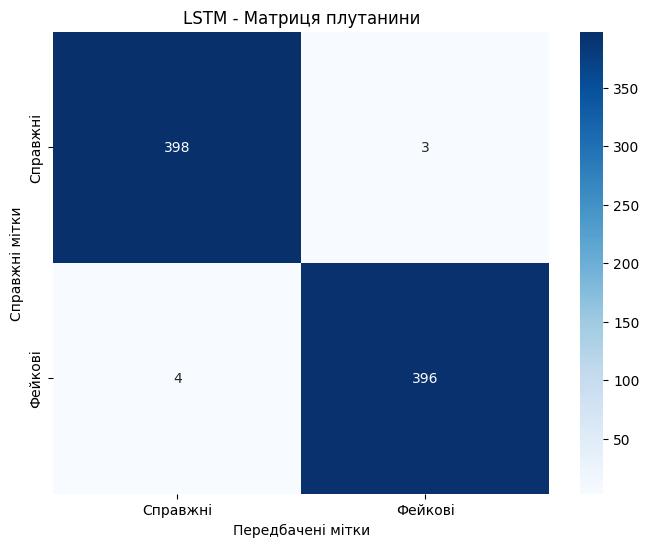

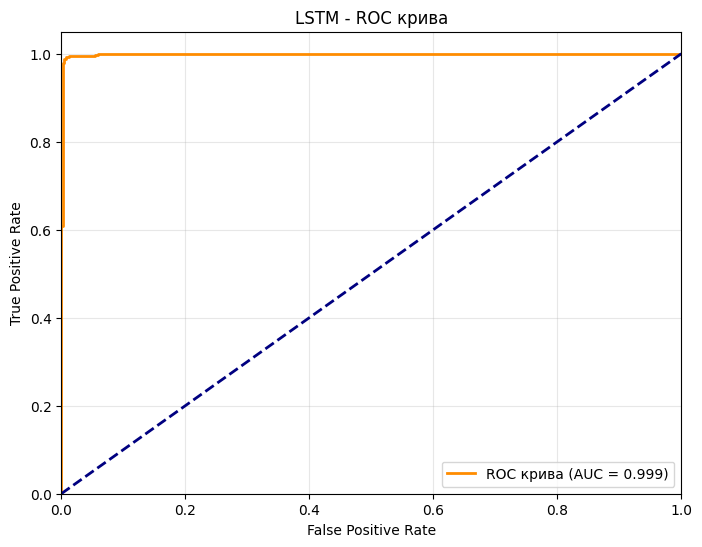


Час навчання LSTM: 401.91 секунд

ПОРІВНЯННЯ МОДЕЛЕЙ

Порівняння продуктивності:
         Метрика    RNN   LSTM
        Точність 0.5793 0.9913
   Прецизійність 0.5802 0.9925
         Повнота 0.5700 0.9900
       F1-оцінка 0.5750 0.9912
         ROC AUC 0.5805 0.9987
Час навчання (с)  75.56 401.91

Аналіз покращення (LSTM vs RNN):
      Метрика  Значення RNN  Значення LSTM  Покращення
     Точність      0.579276       0.991261    0.411985
Прецизійність      0.580153       0.992481    0.412329
      Повнота      0.570000       0.990000    0.420000
    F1-оцінка      0.575032       0.991239    0.416208
      ROC AUC      0.580461       0.998678    0.418217

Складність моделей:
Параметри RNN: 2,062,593
Параметри LSTM: 2,631,041
LSTM має у 1.28 разів більше параметрів ніж RNN

Порівняння часу навчання:
RNN: 75.56 секунд
LSTM: 401.91 секунд
LSTM навчається у 5.32 разів повільніше ніж RNN

ВИСНОВОК
✓ LSTM перевершує RNN на 72.38% за F1-оцінкою
  Очікуваний результат: LSTM краще обробляє довг

In [ ]:
# ============================================
# PART 10: RUN EXPERIMENT AND SAVE RESULTS
# ============================================

if __name__ == "__main__":
    # Run the experiment with NLTK tokenization
    print("Запуск експерименту з класифікації фейкових новин...")
    print("Порівняння Simple RNN vs LSTM з використанням NLTK токенізації.")
    print("="*60)
    
    results = run_experiment_with_nltk()
    
    if results is not None:
        print("\n" + "="*60)
        print("ЕКСПЕРИМЕНТ УСПІШНО ЗАВЕРШЕНО!")
        print("="*60)
        
        # Save results to files
        print("\nЗбереження результатів у файли...")
        
        # Save metrics
        metrics_df = pd.DataFrame({
            'Модель': ['RNN', 'LSTM'],
            'Точність': [results['rnn_metrics']['accuracy'], results['lstm_metrics']['accuracy']],
            'Прецизійність': [results['rnn_metrics']['precision'], results['lstm_metrics']['precision']],
            'Повнота': [results['rnn_metrics']['recall'], results['lstm_metrics']['recall']],
            'F1_оцінка': [results['rnn_metrics']['f1'], results['lstm_metrics']['f1']],
            'ROC_AUC': [results['rnn_metrics']['roc_auc'], results['lstm_metrics']['roc_auc']],
            'Параметри': [results['rnn_params'], results['lstm_params']],
            'Час_навчання_с': [results['rnn_time'], results['lstm_time']]
        })
        
        metrics_df.to_csv('fake_news_results_nltk.csv', index=False, encoding='utf-8-sig')
        print("✓ Результати збережено у 'fake_news_results_nltk.csv'")
        
        # Save comparison table
        results['comparison'].to_csv('model_comparison_nltk.csv', index=False, encoding='utf-8-sig')
        print("✓ Порівняння моделей збережено у 'model_comparison_nltk.csv'")
        
        # Save improvement analysis
        results['improvements'].to_csv('improvement_analysis_nltk.csv', index=False, encoding='utf-8-sig')
        print("✓ Аналіз покращення збережено у 'improvement_analysis_nltk.csv'")
        
        print("\n✓ Візуалізації згенеровано та відображено")
        print("\nЕксперимент завершено успішно!")